# Adrian Morejon: Best Lefty Reliever in Baseball

Morejon vs every left-handed reliever with 30+ IP in 2026, from FanGraphs leaderboard exports. Run top to bottom from this folder.

## 1. Elite categories (90th percentile or higher)

63 lefty relievers with 30+ IP
Metrics at 90th percentile or higher: ['Pitching+', 'Stuff+', 'SIERA', 'xFIP-', 'xFIP', 'FIP', 'Location+', 'K-BB%', 'K/BB', 'FIP-']


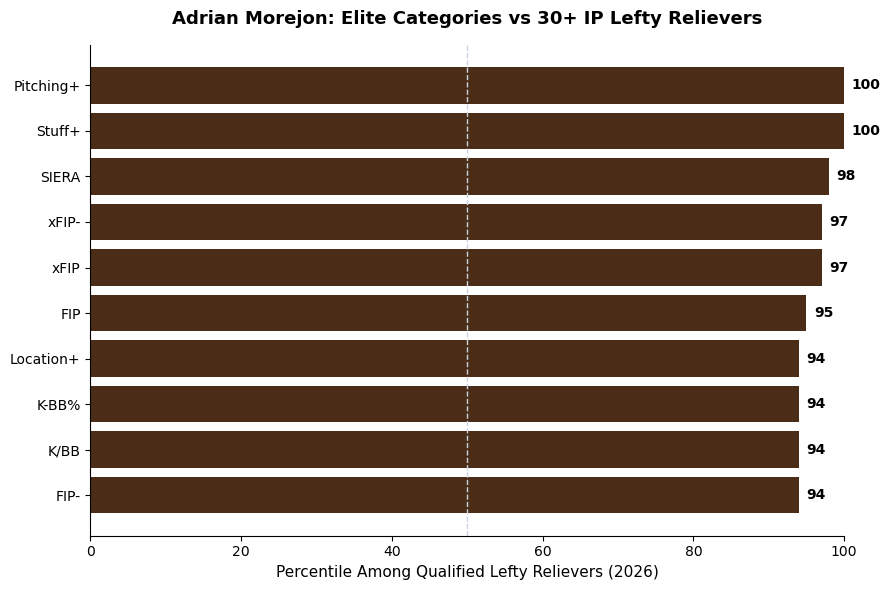

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import percentileofscore

f10 = pd.read_csv('lefty_rp_pitch_models_2026.csv')
f11 = pd.read_csv('lefty_rp_advanced_2026.csv')
f12 = pd.read_csv('lefty_rp_standard_2026.csv')
f13 = pd.read_csv('lefty_rp_win_probability_2026.csv')

merged = f11.merge(f10[['MLBAMID','Stuff+','Location+','Pitching+']], on='MLBAMID', how='left')
merged = merged.merge(f12[['MLBAMID','SV','HLD','IP','G']], on='MLBAMID', how='left')
merged = merged.merge(f13[['MLBAMID','WPA','WPA/LI','Clutch','pLI']], on='MLBAMID', how='left')

merged = merged[merged['IP'] >= 30].copy()
print(merged.shape[0], "lefty relievers with 30+ IP")

morejon_row = merged[merged['Name']=='Adrian Morejon'].iloc[0]

metrics = {
    "Pitching+": ("Pitching+", False),
    "Stuff+": ("Stuff+", False),
    "Location+": ("Location+", False),
    "K-BB%": ("K-BB%", False),
    "K%": ("K%", False),
    "K/9": ("K/9", False),
    "K/BB": ("K/BB", False),
    "FIP-": ("FIP-", True),
    "xFIP-": ("xFIP-", True),
    "SIERA": ("SIERA", True),
    "FIP": ("FIP", True),
    "xFIP": ("xFIP", True),
    "BB/9": ("BB/9", True),
    "HR/9": ("HR/9", True),
    "WHIP": ("WHIP", True),
    "AVG": ("AVG", True),
    "WPA/LI": ("WPA/LI", False),
    "WPA": ("WPA", False),
    "Clutch": ("Clutch", False),
}

results = {}
for label, spec in metrics.items():
    col, lower_is_better = spec
    values = merged[col].dropna()
    if pd.isna(morejon_row[col]):
        continue
    pct = percentileofscore(values, morejon_row[col])
    if lower_is_better:
        pct = 100 - pct
    results[label] = round(pct)

results = {k: v for k, v in results.items() if v >= 90}
results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))
labels = list(results.keys())
values = list(results.values())

print("Metrics at 90th percentile or higher:", labels)

brown = "#4a2c17"

fig, ax = plt.subplots(figsize=(9, max(4, len(labels) * 0.6)))
fig.patch.set_facecolor("white")
bars = ax.barh(labels, values, color=brown)
ax.set_xlim(0, 100)
ax.set_xlabel("Percentile Among Qualified Lefty Relievers (2026)", fontsize=11)
title_text = "Adrian Morejon: Elite Categories vs 30+ IP Lefty Relievers"
ax.set_title(title_text, fontsize=13, fontweight="bold", pad=15)
ax.invert_yaxis()
ax.axvline(50, color="#cbd5e1", linewidth=1, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for bar, val in zip(bars, values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, str(val), va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/morejon_elite_categories_2026.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Full percentile profile

{'Pitching+': 100, 'Stuff+': 100, 'SIERA': 98, 'xFIP-': 97, 'K-BB%': 94, 'FIP-': 94, 'Location+': 94, 'HR/9': 89, 'BB/9': 81, 'WPA/LI': 78, 'K/9': 78, 'ERA': 65}


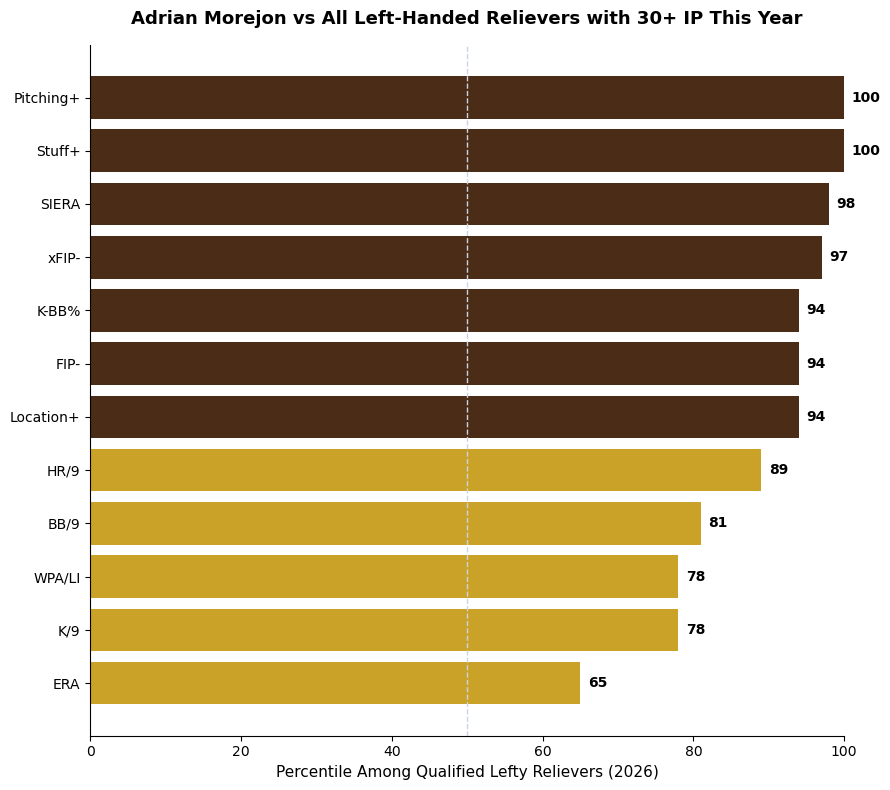

In [2]:
# Full percentile profile: every metric, brown = 90th percentile or higher, gold = below
profile = ["Pitching+", "Stuff+", "SIERA", "xFIP-", "K-BB%", "FIP-", "Location+", "HR/9", "BB/9", "WPA/LI", "K/9", "ERA"]
lower_better = {"SIERA", "xFIP-", "FIP-", "HR/9", "BB/9", "ERA"}
pcts = {}
for col in profile:
    pct = percentileofscore(merged[col].dropna(), morejon_row[col])
    pcts[col] = round(100 - pct if col in lower_better else pct)
pcts = dict(sorted(pcts.items(), key=lambda x: x[1], reverse=True))
labels, values = list(pcts.keys()), list(pcts.values())
print(pcts)

brown, gold = "#4a2c17", "#c9a227"
fig, ax = plt.subplots(figsize=(9, 8))
fig.patch.set_facecolor("white")
bars = ax.barh(labels, values, color=[brown if v >= 90 else gold for v in values])
ax.set_xlim(0, 100)
ax.set_xlabel("Percentile Among Qualified Lefty Relievers (2026)", fontsize=11)
ax.set_title("Adrian Morejon vs All Left-Handed Relievers with 30+ IP This Year", fontsize=13, fontweight="bold", pad=15)
ax.invert_yaxis()
ax.axvline(50, color="#cbd5e1", linewidth=1, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for bar, val in zip(bars, values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2, str(val), va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/morejon_percentiles_2026.png", dpi=200, bbox_inches="tight")
plt.show()